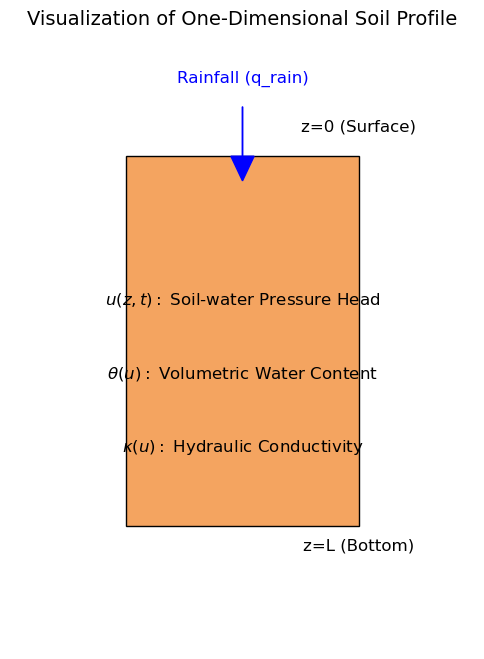

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a figure and axis
fig, ax = plt.subplots(figsize=(6, 8))

# Draw the soil profile
soil_profile = patches.Rectangle((0.25, 0.25), 0.5, 0.75, edgecolor='black', facecolor='sandybrown')
ax.add_patch(soil_profile)

# Add annotations for depth
ax.annotate('z=0 (Surface)', xy=(0.75, 1.05), fontsize=12, ha='center')
ax.annotate('z=L (Bottom)', xy=(0.75, 0.2), fontsize=12, ha='center')

# Draw arrows for rainfall
ax.arrow(0.5, 1.1, 0, -0.1, head_width=0.05, head_length=0.05, fc='blue', ec='blue')
ax.annotate('Rainfall (q_rain)', xy=(0.5, 1.15), fontsize=12, ha='center', color='blue')

# Add annotations for variables inside the soil profile
ax.annotate(r'$u(z, t): \ \mathrm{Soil\text{-}water \ Pressure\ Head}$', xy=(0.5, 0.7), fontsize=12, ha='center')
ax.annotate(r'$\theta(u): \ \mathrm{Volumetric\ Water\ Content}$', xy=(0.5, 0.55), fontsize=12, ha='center')
ax.annotate(r'$\kappa(u): \ \mathrm{Hydraulic\ Conductivity}$', xy=(0.5, 0.4), fontsize=12, ha='center')

# Set limits and remove axes
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.25)
ax.axis('off')

# Add title
plt.title('Visualization of One-Dimensional Soil Profile', fontsize=14)

# Show the plot
plt.show()


In [2]:
pip install pandas matplotlib openpyxl


Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = r'C:\Users\ss4432\study\Book1.xlsx'
data = pd.read_excel(file_path)

# Display the first few rows of the dataframe to understand its structure
print(data.head())

# Plotting
plt.figure(figsize=(12, 8))

# Plot each variable
plt.plot(data['Depth [L]'], data['Head [L]'], label='Head [L]')
plt.plot(data['Depth [L]'], data['Moisture [-]'], label='Moisture [-]')
plt.plot(data['Depth [L]'], data['K [L/T]'], label='K [L/T]')
plt.plot(data['Depth [L]'], data['C [1/L]'], label='C [1/L]')
plt.plot(data['Depth [L]'], data['Flux [L/T]'], label='Flux [L/T]')
plt.plot(data['Depth [L]'], data['Sink [1/T]'], label='Sink [1/T]')
plt.plot(data['Depth [L]'], data['Kappa [-]'], label='Kappa [-]')
plt.plot(data['Depth [L]'], data['v/KsTop [-]'], label='v/KsTop [-]')
plt.plot(data['Depth [L]'], data['Temp [C]'], label='Temp [C]')

# Customize the plot
plt.xlabel('Depth [L]')
plt.ylabel('Values')
plt.title('Hydrus-1D Output Data')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


Empty DataFrame
Columns: []
Index: []


KeyError: 'Depth [L]'

<Figure size 1200x800 with 0 Axes>

In [5]:
import os

def find_file(filename, search_path):
    for root, dirs, files in os.walk(search_path):
        if filename in files:
            return os.path.join(root, filename)
    return None

# Specify the filename
filename = 'Book1.xlsx'

# Specify the search path (e.g., current directory)
search_path = os.getcwd()

# Find the file
file_path = find_file(filename, search_path)

if file_path:
    print(f"File found: {file_path}")
else:
    print("File not found")


File found: C:\Users\ss4432\study\Book1.xlsx


In [2]:
import pandas as pd

# Load the Excel file
file_path = r'C:\Users\ss4432\study\Book1.xlsx'
data = pd.read_excel(file_path, sheet_name='data')

# Display the column names and the first few rows of the dataframe to understand its structure
print("Column names:", data.columns)
print(data.head())


Column names: Index(['Node', 'Depth [L]', 'Head [L]', 'Moisture [-]', 'K [L/T]', 'C [1/L]',
       'Flux [L/T]', 'Sink [1/T]', 'Kappa [-]', 'v/KsTop [-]', 'Temp [C]'],
      dtype='object')
   Node  Depth [L]  Head [L]  Moisture [-]  K [L/T]   C [1/L]  Flux [L/T]  \
0     1          0      -100        0.3677   0.3872  0.000794     -0.3872   
1     2         -3      -100        0.3677   0.3872  0.000794     -0.3872   
2     3         -6      -100        0.3677   0.3872  0.000794     -0.3872   
3     4         -9      -100        0.3677   0.3872  0.000794     -0.3872   
4     5        -12      -100        0.3677   0.3872  0.000794     -0.3872   

   Sink [1/T]  Kappa [-]  v/KsTop [-]  Temp [C]  
0           0         -1      -0.0387        20  
1           0         -1      -0.0387        20  
2           0         -1      -0.0387        20  
3           0         -1      -0.0387        20  
4           0         -1      -0.0387        20  


Optimized alpha: 0.073480347595845
Optimized n: 1.1


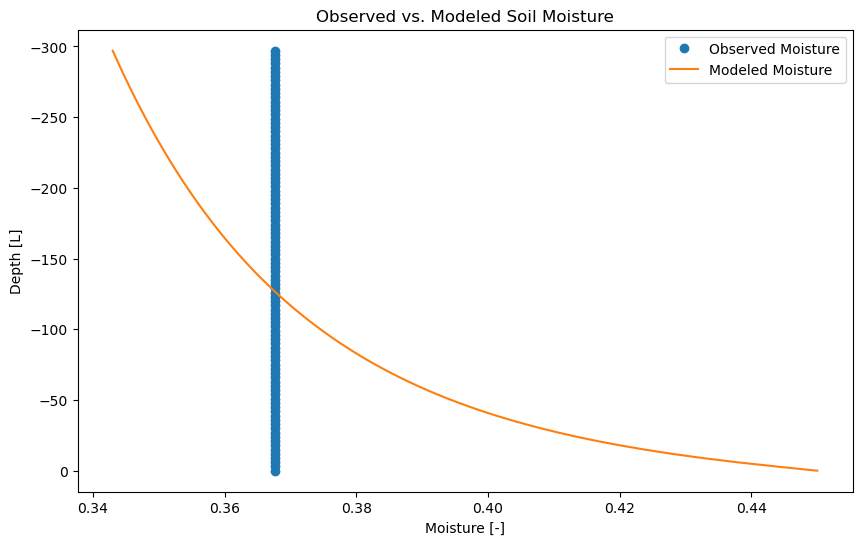

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import os

# Folder to Save Figures In
folder_out = 'Results'  
if not os.path.exists(folder_out):
    os.makedirs(folder_out)

# Load the Excel file
file_path = r'C:\Users\ss4432\study\Book1.xlsx'
data = pd.read_excel(file_path, sheet_name='data')

# Extract relevant columns
depth = data['Depth [L]']
moisture_observed = data['Moisture [-]']

# Define the Van Genuchten model function
def van_genuchten_model(params, depth):
    theta_r = 0.05  # Residual water content
    theta_s = 0.45  # Saturated water content
    alpha = params[0]
    n = params[1]
    
    # Calculate the effective saturation
    m = 1 - 1/n
    theta = theta_r + (theta_s - theta_r) / (1 + (alpha * np.abs(depth))**n)**m
    return theta

# Define the objective function
def objective_function(params, moisture_observed, depth):
    moisture_modeled = van_genuchten_model(params, depth)
    error = np.sum((moisture_observed - moisture_modeled)**2)
    return error

# Initial guess for the parameters [alpha, n]
initial_guess = [0.05, 1.5]

# Set bounds to ensure physically meaningful parameters
bounds = [(0.001, 0.5), (1.1, 3)]

# Perform optimization
result = minimize(objective_function, initial_guess, args=(moisture_observed, depth), bounds=bounds)
optimized_params = result.x
print('Optimized alpha:', optimized_params[0])
print('Optimized n:', optimized_params[1])

# Calculate the modeled moisture using the optimized parameters
moisture_modeled = van_genuchten_model(optimized_params, depth)

# Plot observed vs. modeled moisture
plt.figure(figsize=(10, 6))
plt.plot(moisture_observed, depth, 'o', label='Observed Moisture')
plt.plot(moisture_modeled, depth, '-', label='Modeled Moisture')
plt.gca().invert_yaxis()  # Depth increases downwards
plt.xlabel('Moisture [-]')
plt.ylabel('Depth [L]')
plt.title('Observed vs. Modeled Soil Moisture')
plt.legend()
plt.savefig(f'{folder_out}/results.pdf')
plt.show()


   Node  Depth [L]  Head [L]  Moisture [-]  K [L/T]   C [1/L]  Flux [L/T]  \
0     1          0      -100        0.3677   0.3872  0.000794     -0.3872   
1     2         -3      -100        0.3677   0.3872  0.000794     -0.3872   
2     3         -6      -100        0.3677   0.3872  0.000794     -0.3872   
3     4         -9      -100        0.3677   0.3872  0.000794     -0.3872   
4     5        -12      -100        0.3677   0.3872  0.000794     -0.3872   

   Sink [1/T]  Kappa [-]  v/KsTop [-]  Temp [C]  
0           0         -1      -0.0387        20  
1           0         -1      -0.0387        20  
2           0         -1      -0.0387        20  
3           0         -1      -0.0387        20  
4           0         -1      -0.0387        20  


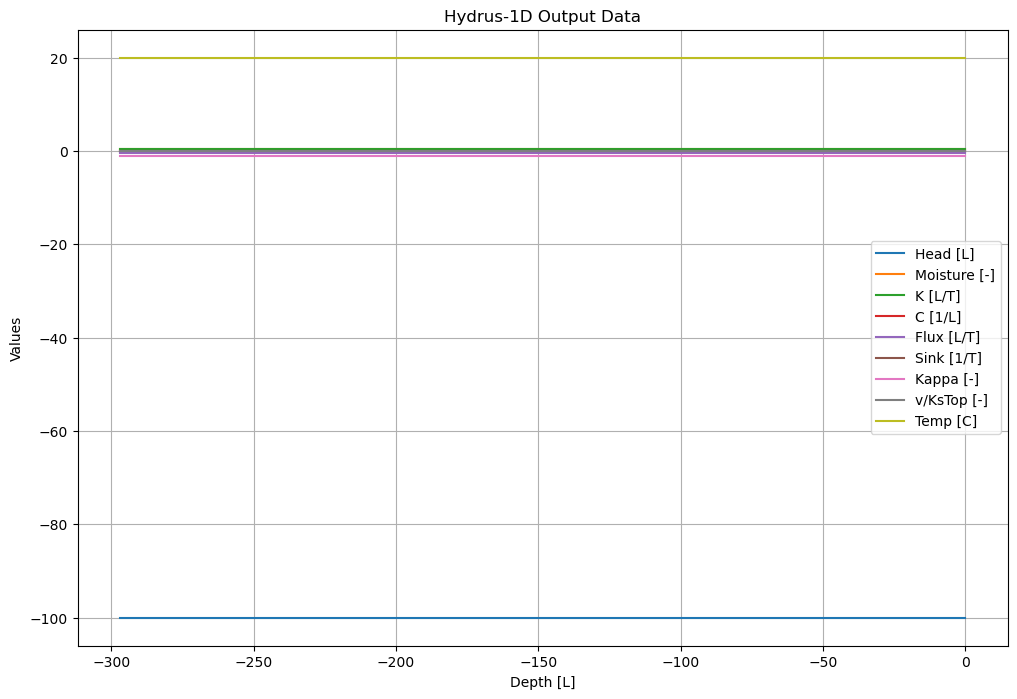

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Display the first few rows of the dataframe to understand its structure
print(data.head())

# Plotting
plt.figure(figsize=(12, 8))

# Plot each variable
plt.plot(data['Depth [L]'], data['Head [L]'], label='Head [L]')
plt.plot(data['Depth [L]'], data['Moisture [-]'], label='Moisture [-]')
plt.plot(data['Depth [L]'], data['K [L/T]'], label='K [L/T]')
plt.plot(data['Depth [L]'], data['C [1/L]'], label='C [1/L]')
plt.plot(data['Depth [L]'], data['Flux [L/T]'], label='Flux [L/T]')
plt.plot(data['Depth [L]'], data['Sink [1/T]'], label='Sink [1/T]')
plt.plot(data['Depth [L]'], data['Kappa [-]'], label='Kappa [-]')
plt.plot(data['Depth [L]'], data['v/KsTop [-]'], label='v/KsTop [-]')
plt.plot(data['Depth [L]'], data['Temp [C]'], label='Temp [C]')

# Customize the plot
plt.xlabel('Depth [L]')
plt.ylabel('Values')
plt.title('Hydrus-1D Output Data')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


   Node  Depth [L]  Head [L]  Moisture [-]  K [L/T]   C [1/L]  Flux [L/T]  \
0     1          0      -100        0.3677   0.3872  0.000794     -0.3872   
1     2         -3      -100        0.3677   0.3872  0.000794     -0.3872   
2     3         -6      -100        0.3677   0.3872  0.000794     -0.3872   
3     4         -9      -100        0.3677   0.3872  0.000794     -0.3872   
4     5        -12      -100        0.3677   0.3872  0.000794     -0.3872   

   Sink [1/T]  Kappa [-]  v/KsTop [-]  Temp [C]  
0           0         -1      -0.0387        20  
1           0         -1      -0.0387        20  
2           0         -1      -0.0387        20  
3           0         -1      -0.0387        20  
4           0         -1      -0.0387        20  


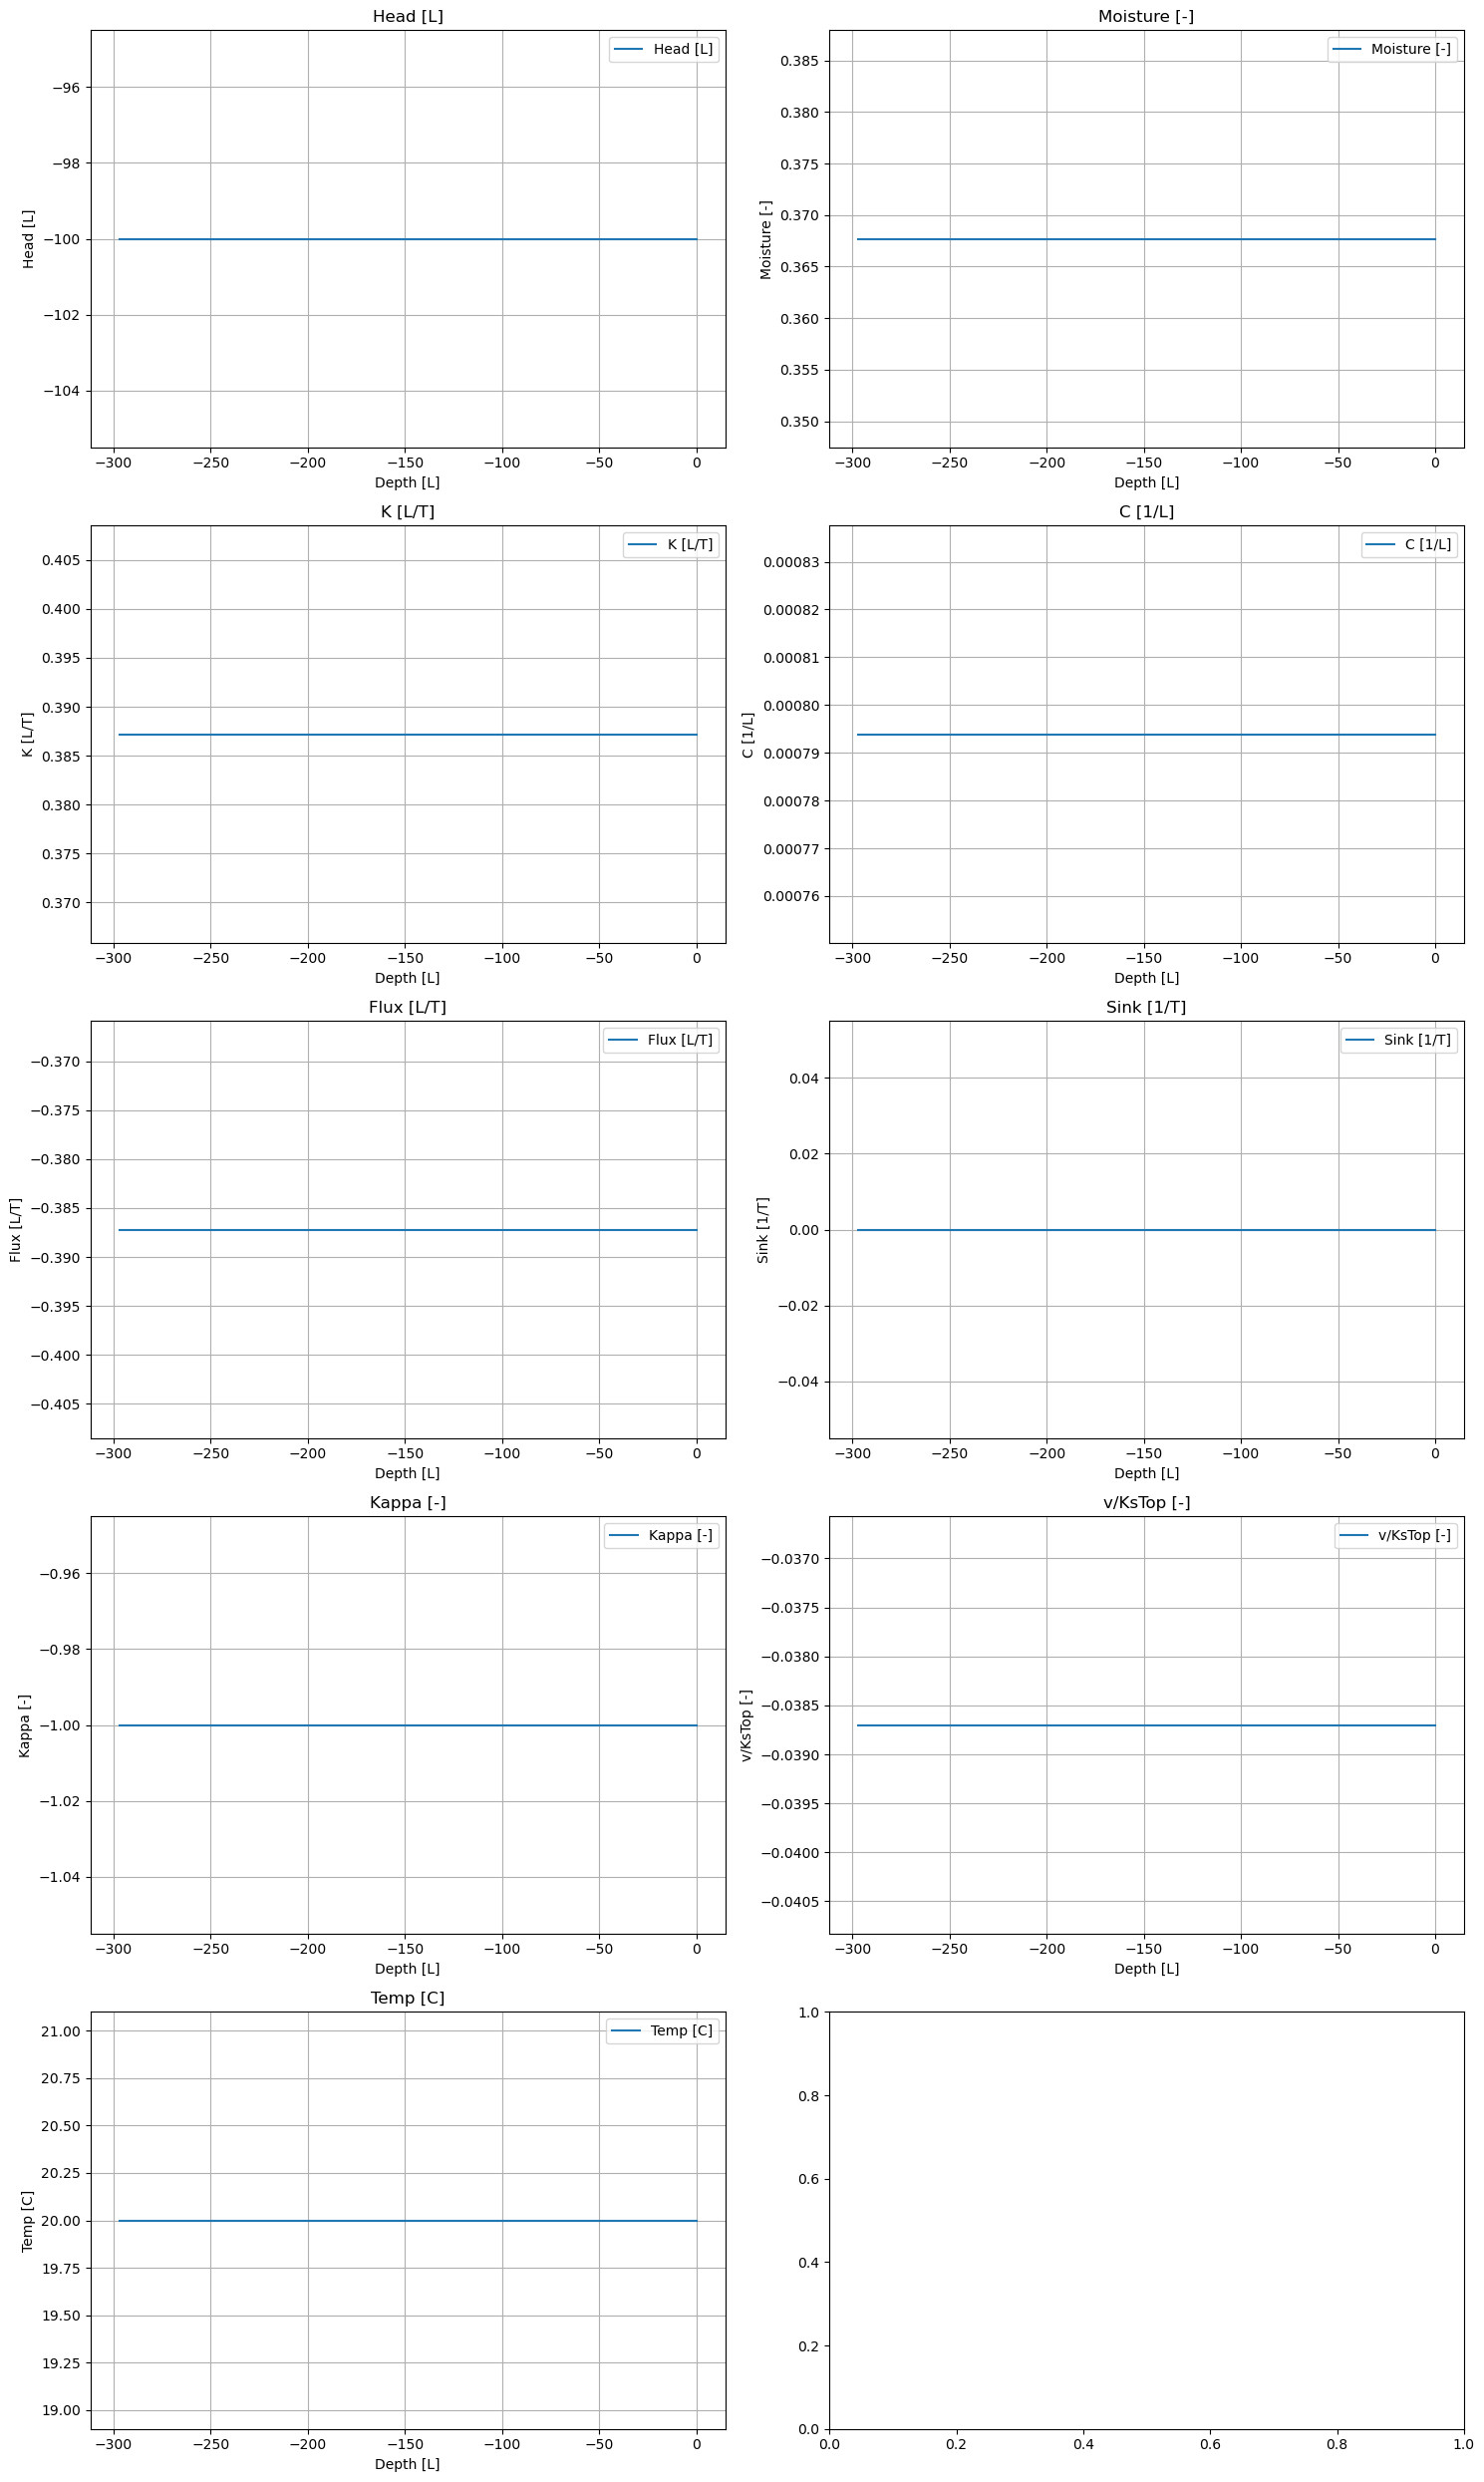

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Display the first few rows of the dataframe to understand its structure
print(data.head())

# Create subplots
fig, axs = plt.subplots(5, 2, figsize=(15, 25))
axs = axs.flatten()

# Define the variables to plot
variables = ['Head [L]', 'Moisture [-]', 'K [L/T]', 'C [1/L]', 'Flux [L/T]', 'Sink [1/T]', 'Kappa [-]', 'v/KsTop [-]', 'Temp [C]']

# Plot each variable in a separate subplot
for i, var in enumerate(variables):
    if var in data.columns:
        axs[i].plot(data['Depth [L]'], data[var], label=var)
        axs[i].set_xlabel('Depth [L]')
        axs[i].set_ylabel(var)
        axs[i].set_title(var)
        axs[i].legend()
        axs[i].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()


2.11000
2.10288
2.08736
2.05861
2.06004
2.06000
Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 6
         Function evaluations: 14
         Gradient evaluations: 7
[0.5182480329049842, 0.5182479994359217, 0.0004063717683782841, 0.00040637200604331126, 0.0003004643985198115, 0.0003004646039745075, 0.00012380444227211754, 0.000123804575709435, 3.249765849958551e-07, 3.249695958417859e-07, 3.328269839493652e-10, 3.33050444339334e-10, 6.958473874319615e-16, 1.056410592195765e-15]
[1.1, 2.11, 2.1028785232244918, 2.0873624581381542, 2.0586135346943895, 2.0600443949381115, 2.0600000641909375]


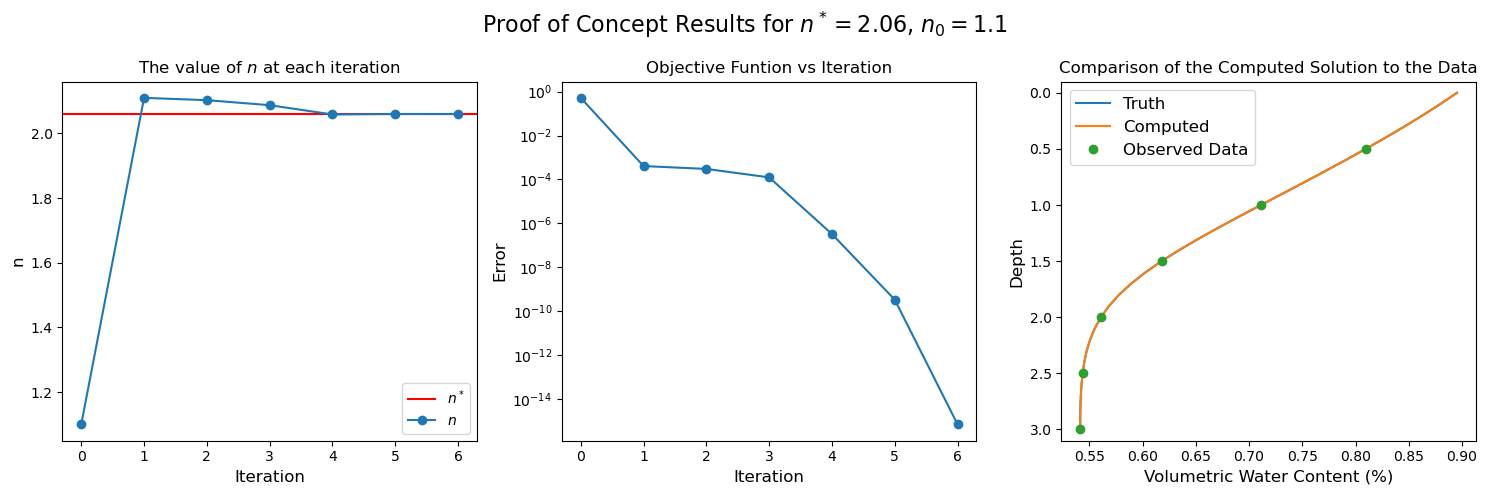

In [1]:
#%% Importing packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sympy import symbols, diff, lambdify
from IPython.display import HTML
from scipy.optimize import minimize 
from functions_new import * 
import os

#Folder to Save Figures In
folder_out = 'Results'  #change to avoid overwriting! 
if not os.path.exists(folder_out):
    os.makedirs(folder_out)

#%% Setting the Parameters

#PDE parameters: creating my finite difference grid, and defined the IC and inflow values.
six_mult = 5
N = 6*six_mult - 1  # Number of cells (spatial) - this needs to be a (multiple of 6)-1 (as i want my grid points to overlap with my measurement locations)
dx = 1.0 / N  # Cell size
dt = 0.001  # Time step
T = 0.5  # Total time
u_inflow = -0.5 #inflow boundary condition
u0 = -1.5 #initial condition
grid = np.linspace(0, 3, N+2)

#Storage arrays
params_at_iterations = []
model_results_at_iterations = []
error_at_iterations = []

#Initial guesses for n0 and the corresponding model solution. 
n0=1.1
initial_guess = n0
params_at_iterations.append(n0)
model_results_at_iterations.append(solve_pde(n0, N, dx, dt, T, u_inflow,u0))




#Synthetic Data!!!!! I solved the forward problem using n^* (the optimal value). To get this data. I then evaluated the solution at the `observed points' to get a vector of data. You can add noise to theta_star if you wish

observed_points = [0.5, 1.0, 1.5, 2.0, 2.5, 3] #6 measured observation points 


n_star = 2.06 #optimal choice 
u_star = solve_pde(n_star, N, dx, dt, T, u_inflow,u0)
theta_star = [theta(ui, n_star) for ui in u_star ] 

#Getting an array of data just at the measurement locations
tol = 1e-9 
loc = np.zeros(1)
for i in observed_points:
    s = (np.where(abs(grid - i) < tol ))[0]
    loc = np.concatenate((loc, s))
locations = np.delete(loc, 0)
locations = locations.astype(int)
observed_data = np.array([theta_star[i] for i in locations])


#%% Defining the Objective function - this is the loss function that is minimised. 

def objective_function(paramn, obs_data, obs_points, N, dx, dt, T, u_inflow,u0):

    # Run the solver and obtain results at observed points and times (for the current parameter value)
    model_results = solve_pde(paramn, N, dx, dt, T, u_inflow,u0)
    model_results_at_iterations.append(model_results) #this stores at each function evaluation (not iteration but we ignore this for now)

    #Finding the specified locations - i.e evaluated this computed solution at the measurement points. 
    grid = np.linspace(0, 3, N+2)
    tol = 1e-7 
    loc = np.zeros(1)
    for i in obs_points:
        s = (np.where(abs(grid - i) < tol ))[0]
        loc = np.concatenate((loc, s))
    
    locations = np.delete(loc, 0)
    locations = locations.astype(int)

    u_model = np.array([theta(model_results[i], paramn) for i in locations])

    # Compute the difference (e.g., mean squared error) between observed data and model results
    error = 0
    for i in range(u_model.size):
        error += np.mean((obs_data - u_model)) ** 2
    error_at_iterations.append(error)
    return error


def store_callback(paramn):
    """
    Callback called after every iteration.

    Storing the current value of paramn, the model results, and the objective function error.

    This is not an efficient way to do this if we care about time...
    """
    params_at_iterations.append(paramn[0])
    print(f'{paramn[0]:.5f}')





#%% THE OPTIMISATION METHOD: Finding n 


result = minimize(objective_function, initial_guess, args=(observed_data, observed_points,N, dx, dt, T, u_inflow,u0),options={'disp': True}, callback = store_callback)
best_fit_n = result.x

print(error_at_iterations)
print(params_at_iterations)

#%% Plotting 



iterations = range(len(params_at_iterations))

plt.figure(figsize=(15, 5))


theta_compute = [theta(ui,  best_fit_n) for ui in model_results_at_iterations[-1]]



plt.subplot(1, 3, 1)
plt.axhline(y=n_star, color='r', linestyle='-', label=r'$n^*$')
plt.plot(iterations, params_at_iterations, '-o', label=r'$n$')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('n', fontsize=12)
plt.title('The value of ' +r'$n$'+' at each iteration', fontsize=12)
plt.legend()


plt.subplot(1, 3, 2)
plt.plot(iterations,error_at_iterations[0::2] , '-o',)
plt.yscale('log')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Objective Funtion vs Iteration', fontsize=12)


plt.subplot(1, 3, 3)
plt.plot(theta_star, grid, '-', label='Truth')
plt.plot(theta_compute, grid, '-', label='Computed')
plt.plot(observed_data, observed_points,  'o', label='Observed Data')
plt.ylim([3.1,-0.1])
plt.ylabel('Depth', fontsize=12)
plt.xlabel('Volumetric Water Content (%)', fontsize=12)
plt.title('Comparison of the Computed Solution to the Data', fontsize=12)
plt.legend(fontsize=12)


plt.suptitle('Proof of Concept Results for '+r'$n^* =$'+str(n_star)+', '+ r'$n_0 =$'+str(n0), fontsize=16)
plt.tight_layout()
plt.savefig('{}/results.pdf'.format(folder_out))
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Example of reading data (modify according to your file format)
data = pd.read_csv('hydrus_output.csv')
from scipy.optimize import minimize

# Define your objective function
def objective_function(paramn, obs_data, obs_points, N, dx, dt, T, u_inflow, u0):
    # Your custom model implementation here
    pass

# Initial guess and observed data
initial_guess = 1.1
observed_data = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])  # Example data

# Run the optimization
result = minimize(objective_function, initial_guess, args=(observed_data, observed_points, N, dx, dt, T, u_inflow, u0))
best_fit_n = result.x
import matplotlib.pyplot as plt

# Plotting example
plt.plot(observed_data, label='Observed Data')
plt.plot(best_fit_n, label='Fitted Model')
plt.legend()
plt.show()
